# Heatmap

Author: Tim Berger 
Date: 20.5.2026

#### Introduction
The Zürich wie neu website allows the residents of Zürich to report damage and defects of the infrastructure of the city. 
Reports are sorted in different categories, such as waste or graphity. 
Illegal disposed waste and littering in the "Abfall/ Sammelstelle" category is reported the most (see category frequency analysis).
To see where the reports of waste and littering cluster the most, this analysis aims to create a heatmap of the waste and littering reports in Züri wie neu

#### Research Question: 
Where do the ilegal desposed waste and littering reports in Züri wie neu cluster within the city?

#### Requirements
To be able to run this code, use the environment sds210 located in the github repository of this project.

### Import Required Packages and Scripts

In [39]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import math
import contextily as ctx
import cmcrameri.cm as cmc

import notebook_utils

### Access and load data

In [84]:
# the notebook_utils file contains all the functions to load the required data from the website of the canton of zurich
# if a dataset failed to load, the corresponding url in the notebook utils file should be checked

zwn_gdf_raw = notebook_utils.import_zwn_data()
neighbourhoods_gdf_raw = notebook_utils.import_neighbourhood_data()


Data züri wie neu loaded sugessfull
Data züri wie neu loaded sugessfull


- clean züri wie neu data

In [ ]:
# filter the züri wie neu data for waste
zwn_waste_gdf = zwn_gdf_raw[zwn_gdf_raw["service_name"]=="Abfall/Sammelstelle"].copy()

# filter for the required columns
zwn_waste_gdf = zwn_waste_gdf[["service_request_id", "title", "geometry"]]



zwn_waste_gdf.head(5)

,service_request_id,title,geometry
4,6,Arbeitskist,POINT (2683094.025 1247762.007)
32,37,Schmiererei,POINT (2681647.035 1244209.988)
43,57,Dieses defe,POINT (2683318.013 1247968.969)
56,72,Defektes Ve,POINT (2681835.03 1249416.051)
68,88,Bitte Abfal,POINT (2678259 1252071.053)


In [ ]:
# reproject to web mercator to be able to load a basemap later
zwn_waste_gdf = zwn_waste_gdf.to_crs(epsg=3857)

- clean neighbourhood data

In [85]:
#filter neighbourhoods data for required columns 
neighbourhoods_gdf = neighbourhoods_gdf_raw[["qname", "qnr", "geometry"]]

### Create a Heatmap

In [ ]:
# decide for a resolution of the grid and a radius for the kernel which should be considered
resolution = 70
r = 300

# extract the x and y coordinates of all reports
x = list(zwn_waste_gdf.geometry.x)
y = list(zwn_waste_gdf.geometry.y)

# calculate the extend of the map
lower_x = round(min(zwn_waste_gdf.geometry.x)-r)
upper_x = round(max(zwn_waste_gdf.geometry.x)+r)
lower_y = round(min(zwn_waste_gdf.geometry.y)-r)
upper_y = round(max(zwn_waste_gdf.geometry.y)+r)

# create an array with all coordinates
x_coords= np.arange(lower_x, upper_x, resolution)
y_coords= np.arange(lower_y, upper_y, resolution)

# create a mesh grid
mesh_x, mesh_y = np.meshgrid(x_coords, y_coords)


# calculate the centre coordinates of the grid
xcentre = mesh_x+(resolution/2)
ycentre = mesh_y+(resolution/2)

print(xcentre)
print(type(xcentre[1]))

# define the kernel function, to determine how the points should be weighted
def kernel_function(d, r):
    dn = d/r
    p = (15/16)*(1-dn**2)**2
    return p

# create a new empty list, which will contain all the intensities
intensity_list = []


# computing density for each grid


for j in range(len(xcentre)):  # iterrates through the rows (as xcentre contains an array for every row with all x values )
    intensity_row = []          #create a new empty list for the row
    for k in range(len(xcentre[0])):    # iterrates through the columns
        kde_value_list = []
        for i in range(len(x)):     # iterrates through all the coordinates of the zwn reports
            # calculate distance between current pixel centre and every zwn report
            d = math.sqrt((xcentre[j][k] - x[i])**2 + (ycentre[j][k] - y[i])**2)
            
            if d <= r:          # if distance is smaller then the kernel radius
                p = kernel_function(d, r)       # calculate the density value with the kernel function
            else:
                p = 0
            kde_value_list.append(p)        
            
        # sum all density values
        total_density = sum(kde_value_list)
        intensity_row.append(total_density)
        
    intensity_list.append(intensity_row)




[[2676938. 2677008. 2677078. ... 2689818. 2689888. 2689958.]
 [2676938. 2677008. 2677078. ... 2689818. 2689888. 2689958.]
 [2676938. 2677008. 2677078. ... 2689818. 2689888. 2689958.]
 ...
 [2676938. 2677008. 2677078. ... 2689818. 2689888. 2689958.]
 [2676938. 2677008. 2677078. ... 2689818. 2689888. 2689958.]
 [2676938. 2677008. 2677078. ... 2689818. 2689888. 2689958.]]
<class 'numpy.ndarray'>


- create a histogram of all densities to be able to plot it reasonable

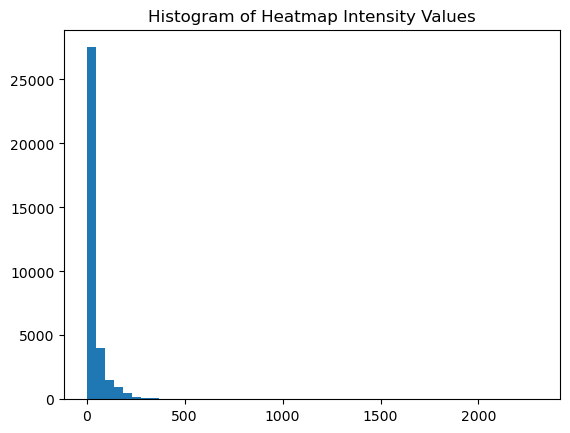

In [67]:
fig, ax = plt.subplots()

all_intensities = []

for row in intensity_list:
    for value in row:
        all_intensities.append(value)

ax.hist(all_intensities, bins=50)
ax.set_title("Histogram of Heatmap Intensity Values")

plt.show()

- as the density data is heavily skewed, the bounds of the colormap are manually restricted

In [81]:
q95 = np.quantile(all_intensities, 0.99)

intensity_restricted = []
for row in intensity_list:
    new_row = []
    for value in row:
        if value < q95:
            new_row.append(value)
        else:
            new_row.append(q95)
    intensity_restricted.append(new_row)

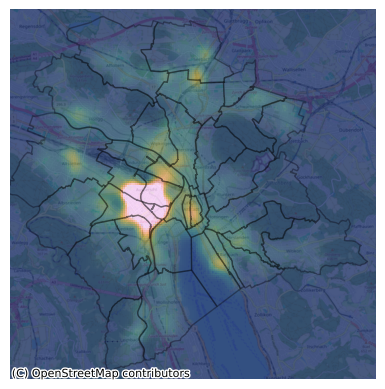

In [91]:
fig, ax = plt.subplots()

# creating an array to have a 2D grid
intensity=np.array(intensity_list)

# create the heatmap layer
heatmap = ax.pcolormesh( mesh_x, mesh_y, intensity_restricted, alpha=0.7, cmap=cmc.batlow)


# add a basemap
ctx.add_basemap(ax, crs="EPSG:2056", source=ctx.providers.OpenStreetMap.Mapnik)

# remove axis
ax.axis("off")

neighbourhoods_gdf.plot(ax= ax, facecolor="none", alpha=0.3)

plt.show()

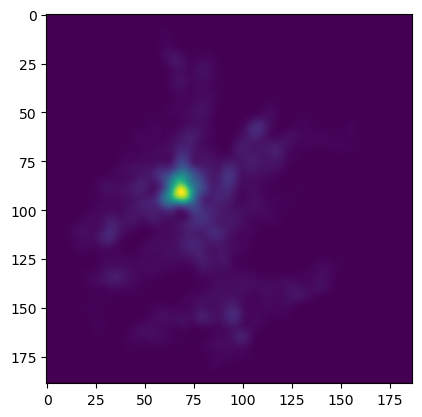

In [56]:
plt.imshow(intensity)
plt.show()